# 02-2. 하이브리드 RAG 평가 — 융합 방식 분석과 도입 권고

`02-1`에서 나온 결과는 두 가지였다.

1. **가설 확인** — 현재 방식(`dense`)은 `identifier`(WF 코드) 질문에서 Hit@5 0.400, MRR 0.112로 무너진다.
   문자 3-gram 어휘 검색(`bm25_tri`)은 같은 문항에서 **전부 1등**(1.000)으로 잡는다.
2. **예상 밖** — 두 방식을 RRF(K=60)로 합치면 `identifier`가 오히려 나빠진다(1.000 → 0.600).
   어휘 검색이 1등으로 잡은 문서를 융합이 10등 밖으로 밀어낸 문항이 3개 있었다.

이 노트북은 2번을 파고들어 **실제로 무엇을 구현해야 하는지** 결정한다.

## 왜 RRF가 손해를 봤는가

RRF는 각 목록에서 r등인 문서에 `1/(K+r)`을 준다. K=60에서:

| 상황 | 점수 |
|---|---|
| 어휘에서 1등, 벡터는 10등 밖 | `1/61` = **0.0164** |
| 양쪽 모두 4~5등 | `1/64 + 1/65` = **0.0310** |

**한쪽만 확신한 정답이, 양쪽이 어중간하게 동의한 오답에 진다.**
`02-1` 설명에서 "양쪽이 동의한 문서를 신뢰한다"고 한 성질이 그대로 약점이 된 것이다.

이건 K값이 후보 풀 크기(308)에 비해 크기 때문이다. 아래에서 K를 낮추면 풀리는지 확인한다.

## 검증할 세 가지 선택지

| 안 | 방식 | 구현 비용 |
|---|---|---|
| ① K 조정 RRF | `1/(K+r)`의 K를 낮춰 상위권을 지배적으로 | 마이그레이션 + 융합 로직 |
| ② 가중 RRF | 어휘 축에 가중치 부여 | ① + 가중치 튜닝 |
| ③ 질의 라우팅 | 질문에 코드 패턴이 있으면 어휘 검색 우선, 없으면 현행 유지 | **기존 `find_task_chunks_by_code` 재사용** |


## 1. 준비 — `02-1`과 동일한 검색기 재구성

노트북 간 상태를 물려받지 않도록 self-contained로 다시 만든다(같은 코드, 같은 결과).

In [1]:
from __future__ import annotations

import json
import math
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sentence_transformers import SentenceTransformer

# 노트북이 docs/notebooks/ 아래로 옮겨져서 cwd가 더 이상 저장소 루트가 아니다.
# `App/`이 보이는 상위 디렉터리까지 거슬러 올라가 루트를 찾는다.
def _find_repo_root(marker: str = "App") -> Path:
    here = Path.cwd()
    for candidate in (here, *here.parents):
        if (candidate / marker).is_dir():
            return candidate
    raise RuntimeError(f"저장소 루트를 찾지 못했습니다 (현재: {here})")


ROOT = _find_repo_root()
OUT = ROOT / "output" / "hybrid_rag_eval"
FIG, DATA = OUT / "figures", OUT / "data"

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

chunks = json.loads((DATA / "chunks_p1.json").read_text(encoding="utf-8"))
evalset = json.loads((DATA / "evalset.json").read_text(encoding="utf-8"))

CHUNK_IDS = [c["id"] for c in chunks]
CONTENTS = [c["content"] for c in chunks]
SOURCE_TYPES = [c["source_type"] for c in chunks]
EMB = np.array([c["embedding"] for c in chunks], dtype=np.float32)
EMB_N = EMB / np.linalg.norm(EMB, axis=1, keepdims=True)

MODEL_NAME = "rhantj/bge-m3-workflow-query-robust"
MODEL_REVISION = "dc328732ab2c3330d38305199e26b2d060586af3"
model = SentenceTransformer(MODEL_NAME, revision=MODEL_REVISION, token=False)
QEMB = np.array(model.encode([q["question"] for q in evalset]), dtype=np.float32)
QEMB_N = QEMB / np.linalg.norm(QEMB, axis=1, keepdims=True)

print(f"청크 {len(chunks)} / 질문 {len(evalset)} / 임베딩 {EMB.shape}")

/Users/gomuseo/Desktop/Python/Work-Flow/App/backend_fastapi/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


청크 378 / 질문 30 / 임베딩 (378, 1024)


In [2]:
def tok_tri(text: str) -> list[str]:
    s = re.sub(r"\s+", " ", text.lower())
    return [s[i:i + 3] for i in range(len(s) - 2)] if len(s) >= 3 else [s]


class BM25:
    def __init__(self, docs, tokenizer, k1=1.2, b=0.75):
        self.tok, self.k1, self.b = tokenizer, k1, b
        self.docs = [tokenizer(d) for d in docs]
        self.dl = np.array([len(d) for d in self.docs], dtype=np.float32)
        self.avgdl = float(self.dl.mean())
        self.tf = [Counter(d) for d in self.docs]
        df = Counter()
        for d in self.docs:
            df.update(set(d))
        n = len(self.docs)
        self.idf = {t: max(0.0, math.log(1 + (n - c + 0.5) / (c + 0.5))) for t, c in df.items()}

    def scores(self, query):
        out = np.zeros(len(self.docs), dtype=np.float32)
        for term in self.tok(query):
            idf = self.idf.get(term)
            if not idf:
                continue
            for i, tf in enumerate(self.tf):
                f = tf.get(term)
                if not f:
                    continue
                out[i] += idf * (f * (self.k1 + 1)) / (f + self.k1 * (1 - self.b + self.b * self.dl[i] / self.avgdl))
        return out


bm25_tri = BM25(CONTENTS, tok_tri)

DENSE = np.stack([EMB_N @ QEMB_N[i] for i in range(len(evalset))])       # (30, 308)
LEX = np.stack([bm25_tri.scores(q["question"]) for q in evalset])        # (30, 308)
print("점수 행렬:", DENSE.shape, LEX.shape)

점수 행렬: (30, 378) (30, 378)


## 2. 지표 함수

In [3]:
TOP_K, DEPTH = 5, 10
CATS = ["identifier", "semantic", "mixed"]


def dcg(rels):
    return sum(r / math.log2(i + 2) for i, r in enumerate(rels))


def score_one(order, gold):
    rels = [1 if CHUNK_IDS[i] in gold else 0 for i in order[:DEPTH]]
    first = next((i + 1 for i, r in enumerate(rels) if r), None)
    # ideal 은 전체 정답 집합 기준(02-1과 동일). 검색된 것 안에서 정렬하면 과대평가된다.
    ideal = [1] * min(len(gold), DEPTH)
    return {
        "hit5": 1 if any(rels[:TOP_K]) else 0,
        "mrr": 1.0 / first if first else 0.0,
        "ndcg": dcg(rels) / dcg(ideal) if ideal else 0.0,
        "first_rank": first,
    }


def evaluate(order_fn, name):
    """order_fn(qi) -> 청크 인덱스 순위 리스트. 전체/분류별 지표를 낸다."""
    per_q = []
    for qi, q in enumerate(evalset):
        per_q.append({"qid": q["id"], "category": q["category"],
                      **score_one(order_fn(qi), set(q["gold_ids"]))})
    res = {"name": name,
           "overall": {k: float(np.mean([r[k] for r in per_q])) for k in ("hit5", "mrr", "ndcg")}}
    for c in CATS:
        sub = [r for r in per_q if r["category"] == c]
        res[c] = {k: float(np.mean([r[k] for r in sub])) for k in ("hit5", "mrr", "ndcg")}
    res["per_q"] = per_q
    return res

## 3. 선택지 ① — RRF의 K값 조정

K가 후보 풀에 비해 크면 등수 차이가 뭉개진다. K를 낮추면 "1등"의 가치가 커진다.

| K | 1등 점수 | 5등 점수 | 1등이 5등보다 몇 배 |
|---|---|---|---|
| 60 | 1/61 = 0.0164 | 1/65 = 0.0154 | 1.07배 |
| 10 | 1/11 = 0.0909 | 1/15 = 0.0667 | 1.36배 |
| 1 | 1/2 = 0.500 | 1/6 = 0.167 | 3.0배 |

K=1이면 한쪽 1등(0.5)이 양쪽 4·5등(0.2+0.167=0.367)을 이긴다. 이론상 문제가 풀린다.
문제는 **`semantic`에서는 그 합의 효과가 실제로 도움이 됐다**는 점이다. 어느 쪽이 얼마나 손해인지 본다.

In [4]:
def rank_map(scores, depth=100):
    order = np.argsort(-scores)[:depth]
    return {int(i): r for r, i in enumerate(order, start=1) if scores[i] > 0}


def rrf_order(qi, k, w_dense=1.0, w_lex=1.0):
    fused = np.zeros(len(CHUNK_IDS), dtype=np.float64)
    for idx, r in rank_map(DENSE[qi]).items():
        fused[idx] += w_dense / (k + r)
    for idx, r in rank_map(LEX[qi]).items():
        fused[idx] += w_lex / (k + r)
    return np.argsort(-fused).tolist()


K_GRID = [1, 2, 5, 10, 20, 40, 60, 100]
k_results = {k: evaluate(lambda qi, k=k: rrf_order(qi, k), f"rrf_k{k}") for k in K_GRID}

print(f"{'K':>4} | {'전체':>6} | {'identifier':>10} {'semantic':>9} {'mixed':>6}   (Hit@5)")
print("-" * 52)
for k in K_GRID:
    r = k_results[k]
    print(f"{k:>4} | {r['overall']['hit5']:>6.3f} | {r['identifier']['hit5']:>10.3f} "
          f"{r['semantic']['hit5']:>9.3f} {r['mixed']['hit5']:>6.3f}")

   K |     전체 | identifier  semantic  mixed   (Hit@5)
----------------------------------------------------
   1 |  0.900 |      1.000     0.700  1.000
   2 |  0.900 |      1.000     0.700  1.000
   5 |  0.900 |      1.000     0.700  1.000
  10 |  0.867 |      0.800     0.800  1.000
  20 |  0.867 |      0.700     0.900  1.000
  40 |  0.833 |      0.600     0.900  1.000
  60 |  0.833 |      0.600     0.900  1.000
 100 |  0.833 |      0.600     0.900  1.000


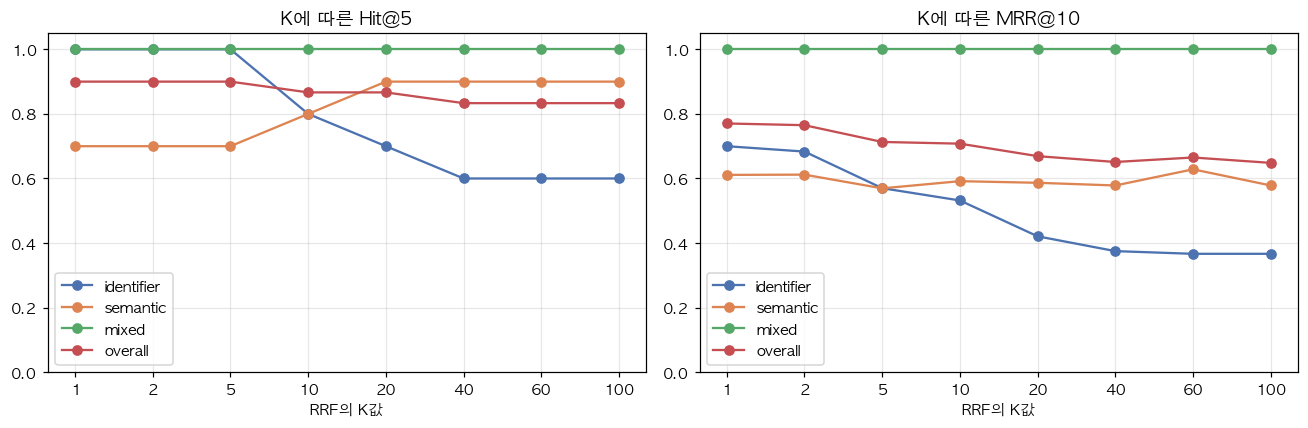

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
xs = list(range(len(K_GRID)))

for cat, color in zip(CATS + ["overall"], ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]):
    axes[0].plot(xs, [k_results[k][cat]["hit5"] for k in K_GRID], "o-", label=cat, color=color)
    axes[1].plot(xs, [k_results[k][cat]["mrr"] for k in K_GRID], "o-", label=cat, color=color)

for ax, title in zip(axes, ["Hit@5", "MRR@10"]):
    ax.set_xticks(xs); ax.set_xticklabels(K_GRID)
    ax.set_xlabel("RRF의 K값"); ax.set_title(f"K에 따른 {title}")
    ax.grid(alpha=0.3); ax.legend(); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(FIG / "02-2_rrf_k_sweep.png", bbox_inches="tight")
plt.show()

## 4. 선택지 ② — 가중 RRF

K는 60으로 두고 어휘 축에 가중치를 준다. `w_lex`가 크면 어휘 검색 쪽 순위를 더 믿는다.

In [6]:
W_GRID = [0.5, 1.0, 1.5, 2.0, 3.0, 5.0]
BEST_K_FOR_W = 60
w_results = {w: evaluate(lambda qi, w=w: rrf_order(qi, BEST_K_FOR_W, 1.0, w), f"rrf_w{w}")
             for w in W_GRID}

print(f"{'w_lex':>6} | {'전체':>6} | {'identifier':>10} {'semantic':>9} {'mixed':>6}   (Hit@5, K=60)")
print("-" * 55)
for w in W_GRID:
    r = w_results[w]
    print(f"{w:>6} | {r['overall']['hit5']:>6.3f} | {r['identifier']['hit5']:>10.3f} "
          f"{r['semantic']['hit5']:>9.3f} {r['mixed']['hit5']:>6.3f}")

 w_lex |     전체 | identifier  semantic  mixed   (Hit@5, K=60)
-------------------------------------------------------
   0.5 |  0.800 |      0.500     0.900  1.000
   1.0 |  0.833 |      0.600     0.900  1.000
   1.5 |  0.767 |      0.700     0.600  1.000
   2.0 |  0.767 |      0.700     0.600  1.000
   3.0 |  0.767 |      0.700     0.600  1.000
   5.0 |  0.867 |      1.000     0.600  1.000


## 5. 선택지 ③ — 질의 라우팅

**융합하지 않는다.** 질문에 업무 코드 패턴(`[A-Za-z]{2,}-\d+`)이 있으면 그 코드를 본문에서
단어 경계로 정확히 찾고, 그 결과를 앞에 놓은 뒤 남는 자리를 기존 벡터 검색으로 채운다.
코드가 없으면 지금과 완전히 동일하게 동작한다.

핵심은 **이미 있는 코드를 재사용한다**는 점이다.
`retrieval_service.find_task_chunks_by_code`가 명령 처리 경로에서 정확히 이 일을 하고 있고,
질문 경로에서만 호출되지 않을 뿐이다. 아래 `exact_code_match`는 그 함수의 SQL 정규식과 동일한 규칙이다.

In [7]:
# find_task_chunks_by_code 의 SQL 정규식과 동일:
#   '(^|[^0-9A-Za-z])' || code || '([^0-9A-Za-z]|$)'
# 앞뒤 경계를 모두 [^0-9A-Za-z]로 잡아야 WF-195가 WF-1950/WF-195A에 오매칭되지 않는다.
CODE_IN_QUERY = re.compile(r"[A-Za-z]{2,}-\d+")


CODE_MATCH_LIMIT = 6  # find_task_chunks_by_code 의 limit 기본값과 동일


def exact_code_match(question: str) -> list[int]:
    codes = CODE_IN_QUERY.findall(question)
    if not codes:
        return []
    hits = []
    for code in codes:
        rx = re.compile(rf"(^|[^0-9A-Za-z]){re.escape(code)}([^0-9A-Za-z]|$)")
        # 운영 함수와 동일하게 task 청크로 제한하고 코드당 최대 CODE_MATCH_LIMIT 건만 취한다.
        found = 0
        for i, content in enumerate(CONTENTS):
            if found >= CODE_MATCH_LIMIT:
                break
            if SOURCE_TYPES[i] == "task" and rx.search(content) and i not in hits:
                hits.append(i)
                found += 1
    return hits


def routed_order(qi):
    exact = exact_code_match(evalset[qi]["question"])
    dense_order = np.argsort(-DENSE[qi]).tolist()
    if not exact:
        return dense_order                      # 코드 없음 -> 현행 그대로
    seen = set(exact)
    return exact + [i for i in dense_order if i not in seen]


n_routed = sum(1 for q in evalset if CODE_IN_QUERY.search(q["question"]))
print(f"라우팅이 발동하는 질문: {n_routed}/{len(evalset)}개")
print("발동 예시:", [q["id"] for q in evalset if CODE_IN_QUERY.search(q["question"])][:5])

라우팅이 발동하는 질문: 10/30개
발동 예시: ['A01', 'A02', 'A03', 'A04', 'A05']


## 6. 최종 비교

기준선(현행 `dense`, 어휘 단독 `bm25_tri`, 기본 RRF)과 세 선택지의 최선을 한자리에 놓는다.

In [8]:
best_k = max(K_GRID, key=lambda k: k_results[k]["overall"]["hit5"])
best_w = max(W_GRID, key=lambda w: w_results[w]["overall"]["hit5"])

candidates = [
    evaluate(lambda qi: np.argsort(-DENSE[qi]).tolist(), "dense (현행)"),
    evaluate(lambda qi: np.argsort(-LEX[qi]).tolist(), "bm25_tri 단독"),
    evaluate(lambda qi: rrf_order(qi, 60), "RRF K=60 (기본)"),
    k_results[best_k] | {"name": f"① RRF K={best_k}"},
    w_results[best_w] | {"name": f"② 가중 RRF w={best_w}"},
    evaluate(routed_order, "③ 질의 라우팅"),
]

hdr = f"{'방식':<20} {'전체':>6} {'ident':>7} {'seman':>7} {'mixed':>7} | {'MRR':>6} {'nDCG':>6}"
print(hdr); print("-" * len(hdr))
for r in candidates:
    print(f"{r['name']:<20} {r['overall']['hit5']:>6.3f} {r['identifier']['hit5']:>7.3f} "
          f"{r['semantic']['hit5']:>7.3f} {r['mixed']['hit5']:>7.3f} | "
          f"{r['overall']['mrr']:>6.3f} {r['overall']['ndcg']:>6.3f}")
print()
print("Hit@5 = 상위 5개 안에 정답 포함 비율 (운영 top_k=5와 동일)")

방식                       전체   ident   seman   mixed |    MRR   nDCG
-------------------------------------------------------------------
dense (현행)            0.733   0.400   0.800   1.000 |  0.579  0.539
bm25_tri 단독           0.800   1.000   0.400   1.000 |  0.773  0.715
RRF K=60 (기본)         0.833   0.600   0.900   1.000 |  0.665  0.600
① RRF K=1             0.900   1.000   0.700   1.000 |  0.770  0.720
② 가중 RRF w=5.0        0.867   1.000   0.600   1.000 |  0.716  0.667
③ 질의 라우팅              0.933   1.000   0.800   1.000 |  0.875  0.812

Hit@5 = 상위 5개 안에 정답 포함 비율 (운영 top_k=5와 동일)


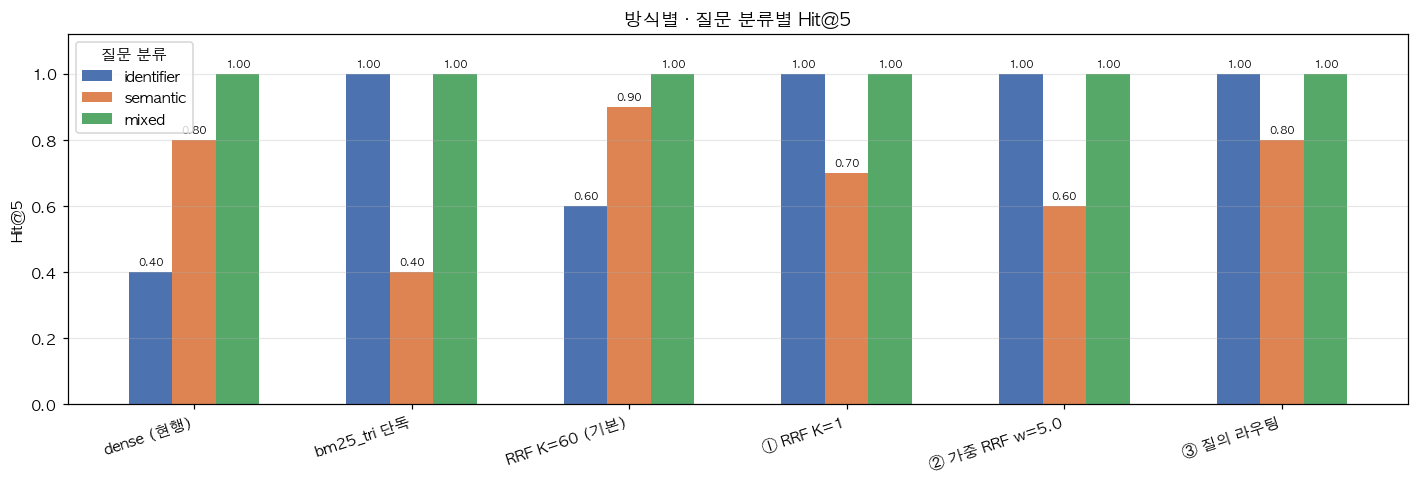

In [9]:
names = [r["name"] for r in candidates]
x = np.arange(len(names))
width = 0.2

fig, ax = plt.subplots(figsize=(13, 4.5))
for i, (cat, color) in enumerate(zip(CATS, ["#4C72B0", "#DD8452", "#55A868"])):
    vals = [r[cat]["hit5"] for r in candidates]
    bars = ax.bar(x + (i - 1) * width, vals, width, label=cat, color=color)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.2f}", ha="center", fontsize=7)

ax.set_xticks(x); ax.set_xticklabels(names, rotation=18, ha="right")
ax.set_ylabel("Hit@5"); ax.set_ylim(0, 1.12)
ax.set_title("방식별 · 질문 분류별 Hit@5")
ax.legend(title="질문 분류"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG / "02-2_final_comparison.png", bbox_inches="tight")
plt.show()

### 현행 대비 문항별 변화

평균이 올라도 **기존에 맞히던 걸 잃으면** 실사용에서는 후퇴로 느껴진다.
현행(`dense`) 대비 좋아진 문항과 나빠진 문항을 각각 센다.

In [10]:
base = {r["qid"]: r for r in candidates[0]["per_q"]}

print(f"{'방식':<20} {'개선':>5} {'악화':>5} {'동일':>5}   악화 문항")
print("-" * 70)
for r in candidates[1:]:
    up = down = same = 0
    worse = []
    for pq in r["per_q"]:
        b = base[pq["qid"]]
        if pq["hit5"] > b["hit5"]:
            up += 1
        elif pq["hit5"] < b["hit5"]:
            down += 1
            worse.append(pq["qid"])
        else:
            same += 1
    print(f"{r['name']:<20} {up:>5} {down:>5} {same:>5}   {', '.join(worse) if worse else '없음'}")

방식                      개선    악화    동일   악화 문항
----------------------------------------------------------------------
bm25_tri 단독              6     4    20   B01, B04, B05, B10
RRF K=60 (기본)            3     0    27   없음
① RRF K=1                6     1    23   B04
② 가중 RRF w=5.0           7     3    20   B01, B04, B05
③ 질의 라우팅                 6     0    24   없음


### 느슨한 문항을 빼도 결론이 같은가

`02`가 문항별 **우연 적중률**을 계산해 `evalset.json`에 남겼다.
`02-1`에서 그 값이 20%를 넘는 문항을 빼자 기준선끼리의 순위가 뒤집혔으므로(0.833 동률의 순서 교체),
**최종 후보들도 같은 검사를 통과하는지** 확인한다. 여기서 1위가 바뀌면 권고를 바꿔야 한다.

In [11]:
# 02-1과 동일하게 evalset.json에서 직접 계산한다(파일 간 불일치가 생길 수 없게).
CHANCE_LIMIT = 0.20
if any("chance_hit5" not in q for q in evalset):
    raise KeyError("evalset.json에 chance_hit5가 없습니다. 노트북 02를 최신 버전으로 다시 실행하세요.")

LOOSE = {q["id"] for q in evalset if q["chance_hit5"] > CHANCE_LIMIT}
print(f"느슨 문항 (우연 적중률 >{CHANCE_LIMIT:.0%}): {sorted(LOOSE) or '없음'}\n")

print(f"{'방식':<20} {'전체':>7} {'느슨 제외':>10} {'차이':>8}")
print("-" * 50)
tight_scores = {}
for r in candidates:
    keep = [pq for pq in r["per_q"] if pq["qid"] not in LOOSE]
    t = float(np.mean([pq["hit5"] for pq in keep]))
    tight_scores[r["name"]] = t
    a = r["overall"]["hit5"]
    print(f"{r['name']:<20} {a:>7.3f} {t:>10.3f} {t - a:>+8.3f}")

rank_all = [r["name"] for r in sorted(candidates, key=lambda r: -r["overall"]["hit5"])]
rank_tight = sorted(tight_scores, key=lambda n: -tight_scores[n])
print()
print("전체 순위     :", " > ".join(rank_all))
print("느슨 제외 순위:", " > ".join(rank_tight))
print()
print("1위 동일" if rank_all[0] == rank_tight[0]
      else f"!! 1위가 바뀜: {rank_all[0]} -> {rank_tight[0]} - 권고 재검토 필요")

느슨 문항 (우연 적중률 >20%): ['B03', 'B08']

방식                        전체      느슨 제외       차이
--------------------------------------------------
dense (현행)             0.733      0.786   +0.052
bm25_tri 단독            0.800      0.857   +0.057
RRF K=60 (기본)          0.833      0.857   +0.024
① RRF K=1              0.900      0.964   +0.064
② 가중 RRF w=5.0         0.867      0.893   +0.026
③ 질의 라우팅               0.933      1.000   +0.067

전체 순위     : ③ 질의 라우팅 > ① RRF K=1 > ② 가중 RRF w=5.0 > RRF K=60 (기본) > bm25_tri 단독 > dense (현행)
느슨 제외 순위: ③ 질의 라우팅 > ① RRF K=1 > ② 가중 RRF w=5.0 > bm25_tri 단독 > RRF K=60 (기본) > dense (현행)

1위 동일


## 7. 저장

In [12]:
summary = {
    "config": {"top_k": TOP_K, "depth": DEPTH, "model": MODEL_NAME, "revision": MODEL_REVISION,
               "n_chunks": len(chunks), "n_questions": len(evalset),
               "best_k": best_k, "best_w_lex": best_w},
    "k_sweep": {str(k): {c: k_results[k][c] for c in ["overall"] + CATS} for k in K_GRID},
    "w_sweep": {str(w): {c: w_results[w][c] for c in ["overall"] + CATS} for w in W_GRID},
    "candidates": [{"name": r["name"], **{c: r[c] for c in ["overall"] + CATS},
                    "per_q": r["per_q"]} for r in candidates],
}
path = DATA / "analysis.json"
path.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
print("저장:", path.relative_to(ROOT), f"({path.stat().st_size/1e3:.0f} KB)")

저장: output/hybrid_rag_eval/data/analysis.json (43 KB)


## 정리

세 선택지를 같은 평가셋으로 비교했다. 숫자에 근거한 도입 권고는
`output/hybrid_rag_eval/RESULT.md`에 정리한다.

**이 평가의 한계** (결론을 읽을 때 반드시 함께 볼 것)

1. **데모 데이터 1개 프로젝트** — 청크 308건, 테스트 문자열로 오염된 부분이 있다.
2. **질문 분포가 인위적** — `identifier`가 10/30(33%)이다. 실사용에서 업무 코드를 직접 대는
   질문의 비율은 알 수 없다(어시스턴트 질의 로그를 저장하지 않는다).
   따라서 **전체 평균보다 분류별 수치**를 보고, 실제 질문 분포를 대입해 판단해야 한다.
3. **검색 품질 ≠ 답변 품질** — 여기서 잰 것은 근거 문서를 찾는 단계까지다.
   최종 답변 품질은 생성 LLM과 프롬프트에도 좌우된다.